In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\NetPopulation.csv') 
print(df)

              STATISTIC Label  Year          Component      UNIT   VALUE
0    Annual Population Change  1951      Annual births  Thousand     NaN
1    Annual Population Change  1951      Annual deaths  Thousand     NaN
2    Annual Population Change  1951   Natural increase  Thousand    26.6
3    Annual Population Change  1951         Immigrants  Thousand     NaN
4    Annual Population Change  1951          Emigrants  Thousand     NaN
..                        ...   ...                ...       ...     ...
595  Annual Population Change  2025         Immigrants  Thousand   125.3
596  Annual Population Change  2025          Emigrants  Thousand    65.6
597  Annual Population Change  2025      Net migration  Thousand    59.7
598  Annual Population Change  2025  Population change  Thousand    78.3
599  Annual Population Change  2025         Population  Thousand  5458.6

[600 rows x 5 columns]


In [28]:
immigrant_df = df[df['Component']=="Immigrants"]
emigrant_df = df[df['Component']=="Emigrants"]
net_df = df[df['Component']=="Net migration"]

print(net_df)

              STATISTIC Label  Year      Component      UNIT  VALUE
5    Annual Population Change  1951  Net migration  Thousand    -35
13   Annual Population Change  1952  Net migration  Thousand    -35
21   Annual Population Change  1953  Net migration  Thousand    -33
29   Annual Population Change  1954  Net migration  Thousand    -36
37   Annual Population Change  1955  Net migration  Thousand    -45
..                        ...   ...            ...       ...    ...
565  Annual Population Change  2021  Net migration  Thousand     21
573  Annual Population Change  2022  Net migration  Thousand     51
581  Annual Population Change  2023  Net migration  Thousand     77
589  Annual Population Change  2024  Net migration  Thousand     79
597  Annual Population Change  2025  Net migration  Thousand     59

[75 rows x 5 columns]


C:\Users\Tom\AppData\Local\Temp\ipykernel_22656\3545332048.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  net_df['VALUE'] = net_df['VALUE'].apply(lambda x: int(x))


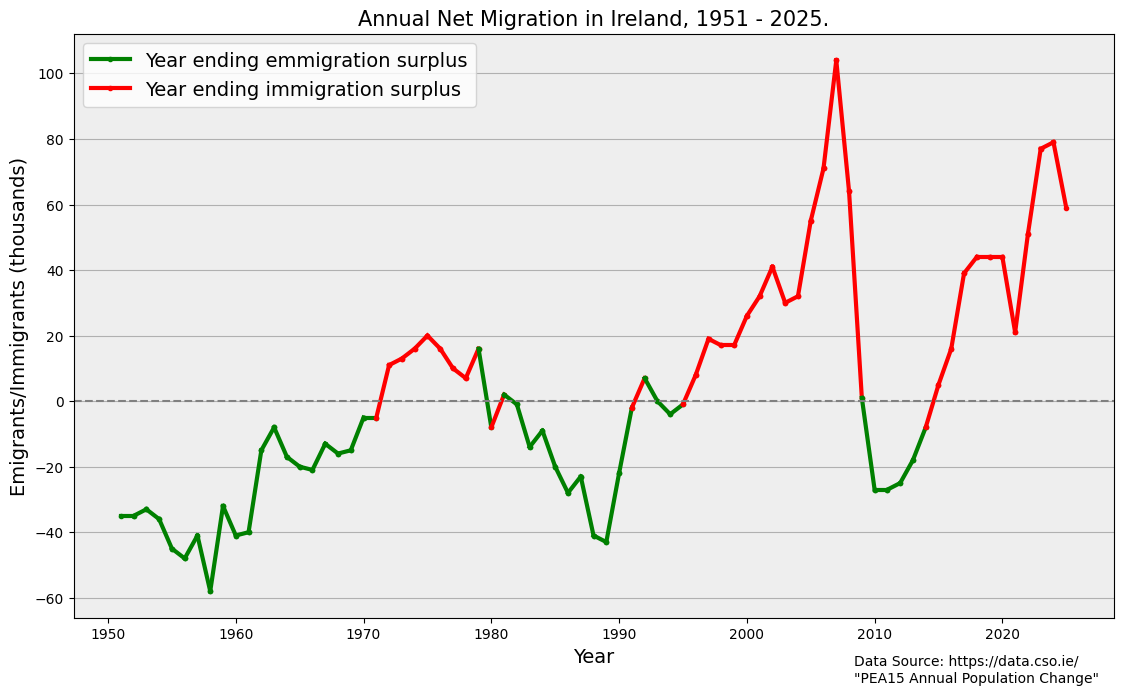

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

for i in range(len(net_df) - 1):
    color = "red" if net_df["VALUE"].iloc[i+1] > 0 else "green"
    if i==1:
        ax.plot(net_df["Year"].iloc[i:i+2].values, net_df["VALUE"].iloc[i:i+2].values, marker=".", color=color, linewidth=3, label="Year ending emmigration surplus")
    elif i==len(net_df)-2:
        ax.plot(net_df["Year"].iloc[i:i+2].values, net_df["VALUE"].iloc[i:i+2].values, marker=".", color=color, linewidth=3, label="Year ending immigration surplus")
    else:
        ax.plot(net_df["Year"].iloc[i:i+2].values, net_df["VALUE"].iloc[i:i+2].values, marker=".", color=color, linewidth=3)
    
ax.axhline(0, color="gray", linestyle="--")

title_string = "Annual Net Migration in Ireland, 1951 - 2025."

plt.title(title_string, fontsize=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Emigrants/Immigrants (thousands)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.legend(fontsize=14) 
plt.grid(True, axis="y")


plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.75, -0.11, "Data Source: https://data.cso.ie/ \n\"PEA15 Annual Population Change\"", ha='left', transform=ax.transAxes)

save_fig = 'NetPopulationLine.png'
plt.savefig(save_fig)

# Show the plot
plt.show()
